# Bank Marketing | ML1 Final Project
## Ethan Ooi, Nathan Myers, Erik Huisman

In [26]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, 
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score)

# Question & Background

This dataset revolves around a Portuguese bank that has made a series of phone call-based campaigns with the intent of getting people to invest in a bank account at their institution. The dataset contains information from previous attempts to call potential customers, and whether they were successful at convincing them or not. In many cases, these customers had been contacted by this bank before the most recent campaign, however we noticed that only a fraction of the people being called would actually accept the bank's offer. As a result, we don't think that the calling campaign that this bank rolls out is the most efficient, so we have decided to find ways to make sure that the bank isn't wasting time by calling unlikely customers. So, the question we are asking in this process is: How can we identify customers most likely to invest so that the bank can prioritize outreach and maximize successful conversions while minimizing unnecessary calls?


In order to increase the efficiency of the bank's calling campaign, we will attempt to find any specific patterns or trends in the dataset that point towards a potential customer, which we will initially perform through Logistic Regression. After running the Logistic Regression model once, we will check the precision and recall of the model, then fine-tune the model via threshold adjustment so it becomes more effective in later attempts be finding the right balance between precision and recall. Alongside the model, we will also run a Random Forest Classification model to see if there is another way to streamline the campaign process. On top of this, both the Logistic Regression and Random Forest models will both be tuned using GridSearchCV, which should hopefully pick on methods to improve effectiveness that weren't picked up in the intial runnings of both of these models.

# Exploratory Data Analysis

In [27]:
# Read data in
df = pd.read_csv('../data/bank-additional-full.csv', sep=';')

In [28]:
print(df.shape)

(41188, 21)


In [29]:
# Before removing nulls
print((df == 'unknown').sum())

age                  0
job                330
marital             80
education         1731
default           8597
housing            990
loan               990
contact              0
month                0
day_of_week          0
duration             0
campaign             0
pdays                0
previous             0
poutcome             0
emp.var.rate         0
cons.price.idx       0
cons.conf.idx        0
euribor3m            0
nr.employed          0
y                    0
dtype: int64


In [30]:
# Remove nulls
df = df[(df['housing'] != 'unknown') & (df['loan'] != 'unknown')]
df = df[df['job'] != 'unknown']
df = df[df['marital'] != 'unknown']
df = df[df['education'] != 'unknown']

In [31]:
# Drop columns 
cols_to_drop = ['default', 'duration', 'previous', 'pdays']
df.drop(columns=cols_to_drop, inplace=True)

print((df == 'unknown').sum())

age               0
job               0
marital           0
education         0
housing           0
loan              0
contact           0
month             0
day_of_week       0
campaign          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


Explanations for dropping columns:
"default" only has 3 samples of "yes" and the other 40,000+ samples are "no" or "unknown". We drop this column because it won't give us any useful information

"duration" is extremely correlated with the target variable

"previous" & "pdays" both tell the same information as poutcome, so we chose to only keep poutcome.

In [32]:
# Split feature & target data
X = df.drop(columns=['y'])
y = (df['y'] == 'yes').astype(int)

# Assign categorical & numeric columns
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
numeric_cols = [c for c in X.columns if c not in categorical_cols]

print('Prevalence:', y.mean().round(3))

Prevalence: 0.111


# Logistic Regression

In [33]:
# Train test split data
X_train_log, X_test_log, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

### Why Do We Scale Features?

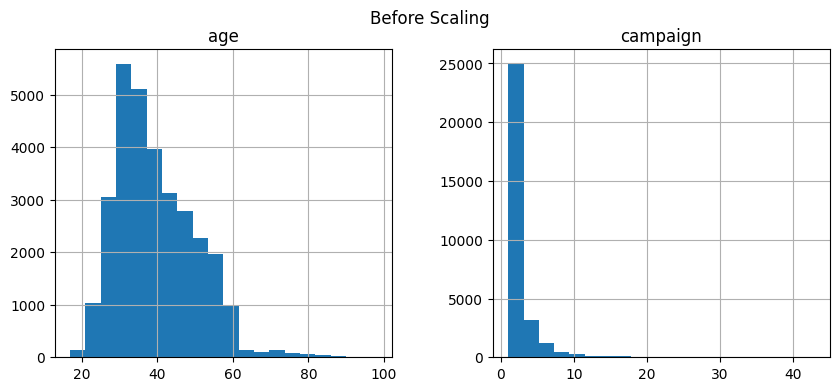

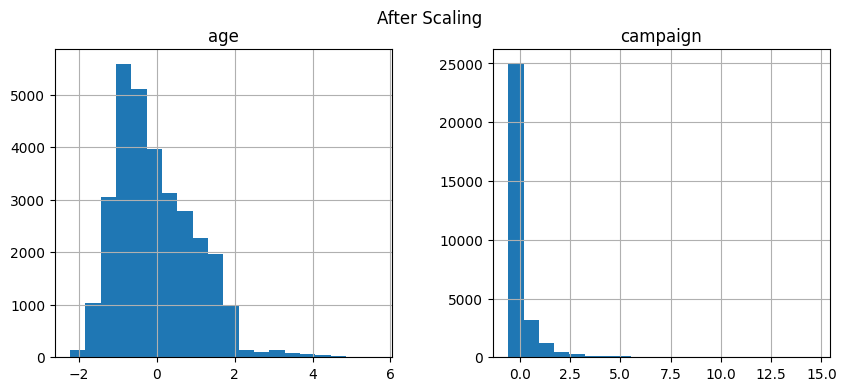

In [38]:
plot_cols = ['age', 'campaign']
X_train_log[plot_cols].hist(bins=20, figsize=(10, 4))
plt.suptitle('Before Scaling')
plt.show()

scaled = StandardScaler().fit_transform(X_train_log[plot_cols])
plot_df = pd.DataFrame(scaled, columns=plot_cols)
plot_df.hist(bins=20, figsize=(10, 4))
plt.suptitle('After Scaling')
plt.show()

Since some numerical features can be heavily skewed, like 'age' and 'campaign', this can make logistic regression highly sensitive to how these features can be scaled, as features with large scales could potentially dominate the regression process. By adjusting the values on the axes, which is a key aspect of scaling, we can ensure that each feature is on a reasonable scale and the model will converge reliably without any hiccups, despite the overall shape of the distribution appearing to have not changed much. 

### Default LogReg (0.50) - Model 1

In [10]:
# Numeric Columns
numeric_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

# Categorical Columns
categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combining Pipelines
preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', categorical_pipeline, categorical_cols)
])

# Making the Full Pipeline
log_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

# Fit default LogReg model
log_pipeline.fit(X_train_log, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains s

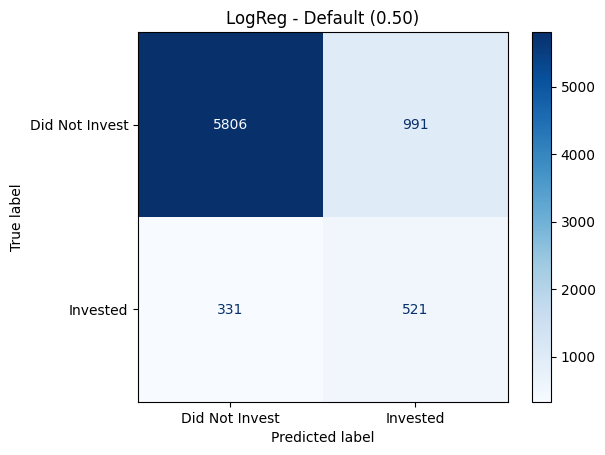

                precision    recall  f1-score   support

Did Not Invest      0.946     0.854     0.898      6797
      Invested      0.345     0.612     0.441       852

      accuracy                          0.827      7649
     macro avg      0.645     0.733     0.669      7649
  weighted avg      0.879     0.827     0.847      7649



In [11]:
# Evaluate default LogReg
def evaluate(model, X_test, y_test, name):
    global y_pred, y_prob
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred),
        display_labels=['Did Not Invest', 'Invested']
    ).plot(cmap='Blues')
    plt.title(name)
    plt.show()
    
    print(classification_report(y_test, y_pred, target_names=['Did Not Invest', 'Invested'], digits=3)
)

evaluate(log_pipeline, X_test_log, y_test, "LogReg - Default (0.50)")

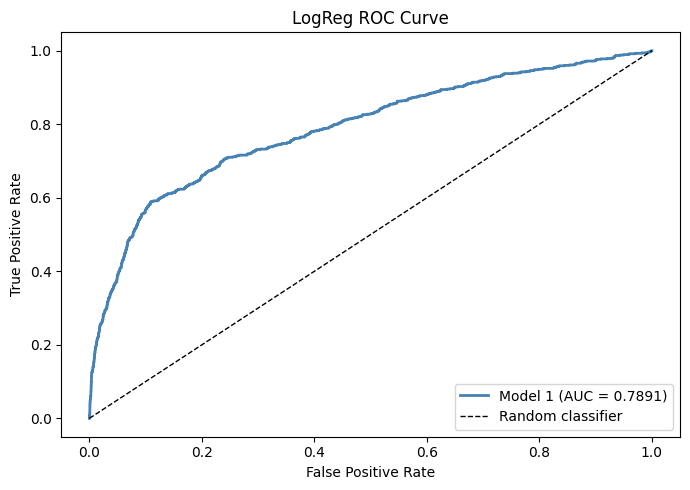

Model 1 ROC-AUC: 0.7891


In [12]:
# ROC AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, lw=2, color='steelblue', label=f'Model 1 (AUC = {auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('LogReg ROC Curve')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(f"Model 1 ROC-AUC: {auc:.4f}")

From what we can see, the model is picking up potential investors, but it still missing out on a large number of investors through misidentifcation. Mislabeling someone who isn't going to invest as a potential investor isn't great either, but it isn't as concerning as labeling a potential investor as someone not worth targeting. As a result, we need to re-tune the model to be more accurate at labeling future investors.

## Lowering the Threshold of our Model

### Threshold tuning
Since false negatives (missing a real investor) cost more than false positives, we lower the threshold to 0.35 to boost recall.

In [13]:
def evaluate_tune(threshold, y_prob, y_test, name):
    y_pred_tuned = (y_prob >= threshold).astype(int)
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, y_pred_tuned),
        display_labels=['Did Not Invest', 'Invested']
    ).plot(cmap='Blues')
    plt.title(name)
    plt.show()
    
    print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Invest', 'Invested']))

### LogReg - Tuned (0.35) - Model 2

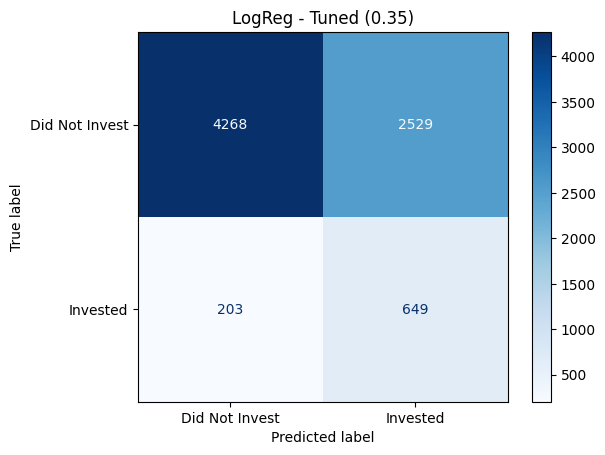

                precision    recall  f1-score   support

Did Not Invest       0.95      0.63      0.76      6797
      Invested       0.20      0.76      0.32       852

      accuracy                           0.64      7649
     macro avg       0.58      0.69      0.54      7649
  weighted avg       0.87      0.64      0.71      7649



In [14]:
evaluate_tune(0.35, y_prob, y_test, "LogReg - Tuned (0.35)")
y_pred_tuned = (y_prob >= 0.35).astype(int)

We've dramatically lowered the number of potential investors we've missed out on, however it did come at the cost of lowering the precision of identifying these potential investors. Nonetheless, we are able to encapsulate more investors by lowering the threshold of our model.

## Precision-Recall Curve For Better Understanding

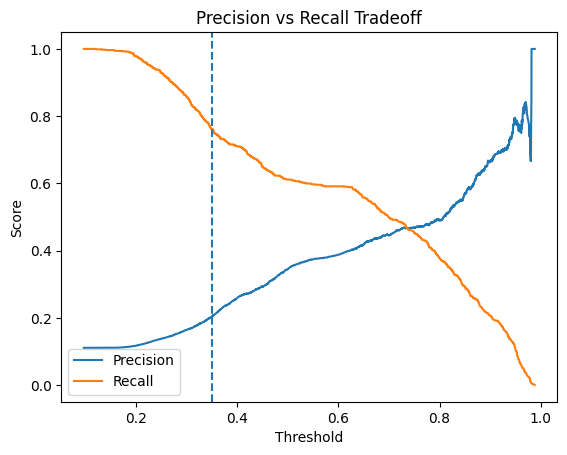

In [15]:
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(x=0.35, linestyle='--')
plt.xlabel('Threshold'); plt.ylabel('Score')
plt.title('Precision vs Recall Tradeoff')
plt.legend()
plt.show()

### LogReg GridSearchCV - Model 3 
Now that we have established a baseline for our model with a threshold of 0.35, we want to tune the hyperparameters for our logistic regression model. By using GridSearchCV, we aren't going to just randomly guess what to tune the paramters to, instead, GridSearchCV allows us to test different combinations using cross-validation and select the model configuration that maximizes our recall since we want to capture as many potential investors as possible. 

In [16]:
log_param_grid = {
    'model__C': [0.01, 0.025, 0.05, 0.1],
    'model__solver': ['lbfgs', 'liblinear', 'saga']
}

log_grid = GridSearchCV(
    log_pipeline, 
    log_param_grid, 
    cv=10, 
    scoring='recall',
    n_jobs=-1,
    verbose=1
)

log_grid.fit(X_train_log, y_train)

best_pipeline = log_grid.best_estimator_
print("Best Parameters:", log_grid.best_params_)
print(f"Best Cross-Validated Recall: {log_grid.best_score_:.4f}")

Fitting 10 folds for each of 12 candidates, totalling 120 fits
Best Parameters: {'model__C': 0.05, 'model__solver': 'liblinear'}
Best Cross-Validated Recall: 0.6201


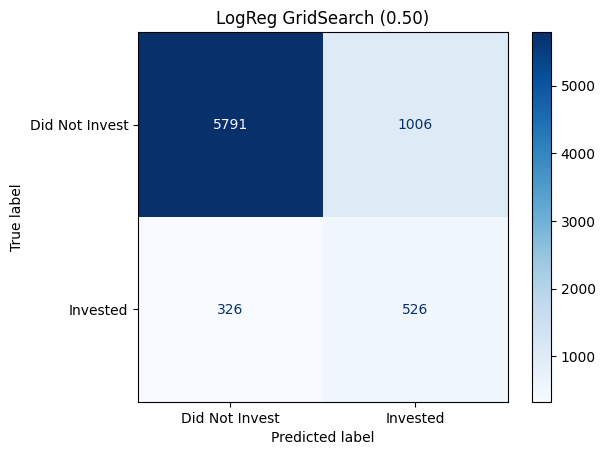

                precision    recall  f1-score   support

Did Not Invest      0.947     0.852     0.897      6797
      Invested      0.343     0.617     0.441       852

      accuracy                          0.826      7649
     macro avg      0.645     0.735     0.669      7649
  weighted avg      0.879     0.826     0.846      7649



In [17]:
evaluate(best_pipeline, X_test_log, y_test, "LogReg GridSearch (0.50)")

### LogReg GridSearch - Tuned (0.35) - Model 4

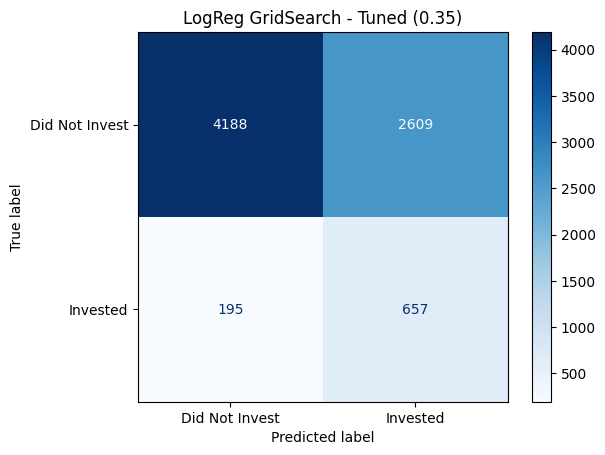

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [18]:
evaluate_tune(0.35, y_prob, y_test, "LogReg GridSearch - Tuned (0.35)")

## Final LogReg Comparison

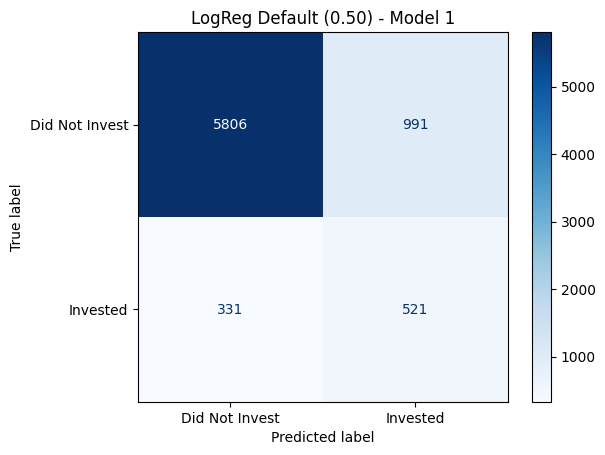

                precision    recall  f1-score   support

Did Not Invest      0.946     0.854     0.898      6797
      Invested      0.345     0.612     0.441       852

      accuracy                          0.827      7649
     macro avg      0.645     0.733     0.669      7649
  weighted avg      0.879     0.827     0.847      7649



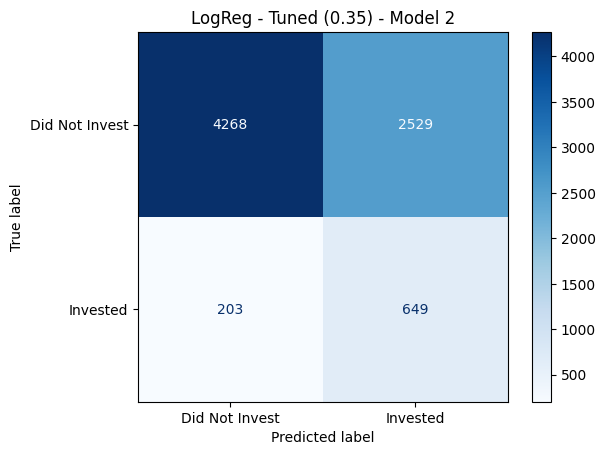

                precision    recall  f1-score   support

Did Not Invest       0.95      0.63      0.76      6797
      Invested       0.20      0.76      0.32       852

      accuracy                           0.64      7649
     macro avg       0.58      0.69      0.54      7649
  weighted avg       0.87      0.64      0.71      7649



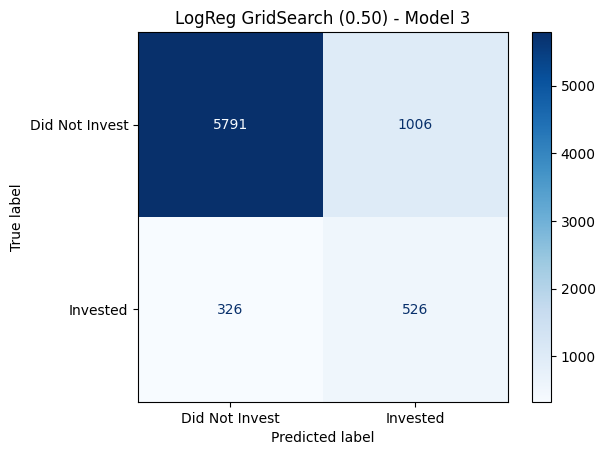

                precision    recall  f1-score   support

Did Not Invest      0.947     0.852     0.897      6797
      Invested      0.343     0.617     0.441       852

      accuracy                          0.826      7649
     macro avg      0.645     0.735     0.669      7649
  weighted avg      0.879     0.826     0.846      7649



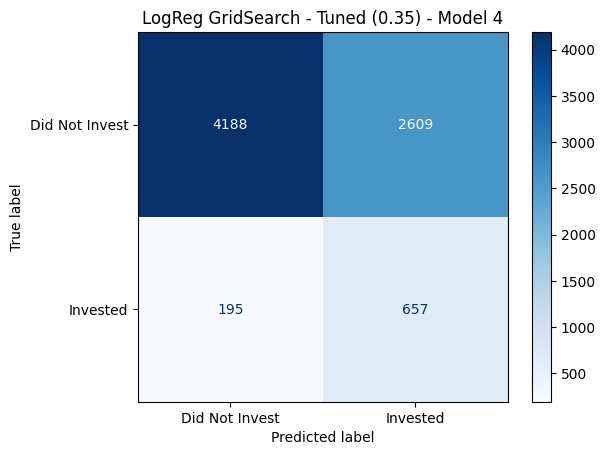

                precision    recall  f1-score   support

Did Not Invest       0.96      0.62      0.75      6797
      Invested       0.20      0.77      0.32       852

      accuracy                           0.63      7649
     macro avg       0.58      0.69      0.53      7649
  weighted avg       0.87      0.63      0.70      7649



In [19]:
evaluate(log_pipeline, X_test_log, y_test, "LogReg Default (0.50) - Model 1")
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_tuned),
    display_labels=['Did Not Invest', 'Invested']
).plot(cmap='Blues')
plt.title('LogReg - Tuned (0.35) - Model 2')
plt.show()
print(classification_report(y_test, y_pred_tuned, target_names=['Did Not Invest', 'Invested']))
evaluate(best_pipeline, X_test_log, y_test, "LogReg GridSearch (0.50) - Model 3")
evaluate_tune(0.35, y_prob, y_test, "LogReg GridSearch - Tuned (0.35) - Model 4")

# Random Forest
Tree-based models don't need scaling. We one-hot encode categoricals and reuse the same train/test split.

In [20]:
# Train Test Split
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=int)

X_train_rf, X_test_rf, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Random Forest (0.50) - Model 1

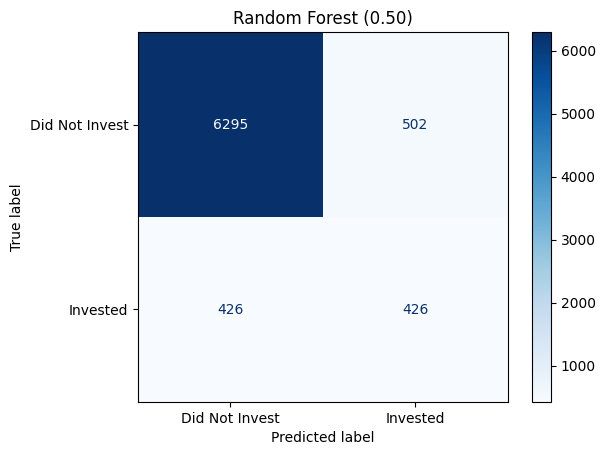

                precision    recall  f1-score   support

Did Not Invest      0.937     0.926     0.931      6797
      Invested      0.459     0.500     0.479       852

      accuracy                          0.879      7649
     macro avg      0.698     0.713     0.705      7649
  weighted avg      0.883     0.879     0.881      7649



In [21]:
# Train & fit model 1
rf1 = RandomForestClassifier(
    n_estimators=300, 
    max_depth=None, 
    min_samples_leaf=2,
    class_weight='balanced',
    n_jobs=-1, 
    random_state=42,
)
rf1.fit(X_train_rf, y_train)

# Results
evaluate(rf1, X_test_rf, y_test, "Random Forest (0.50)")

### Random Forest - Tuned (0.35) - Model 2

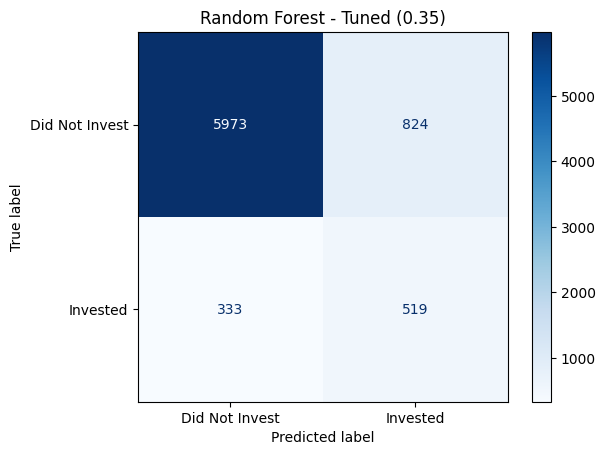

                precision    recall  f1-score   support

Did Not Invest       0.95      0.88      0.91      6797
      Invested       0.39      0.61      0.47       852

      accuracy                           0.85      7649
     macro avg       0.67      0.74      0.69      7649
  weighted avg       0.88      0.85      0.86      7649



In [22]:
evaluate_tune(0.35, y_prob, y_test, "Random Forest - Tuned (0.35)")
y_pred_rf_tuned = (y_prob >= 0.35).astype(int)

Now that we have established a baseline for our model with a threshold of 0.35, we want to tune the hyperparameters for our logistic regression model. By using GridSearchCV, we aren't going to just randomly guess what to tune the paramters to, instead, GridSearchCV allows us to test different combinations using cross-validation and select the model configuration that maximizes our recall since we want to capture as many potential investors as possible. 

### Random Forest GridSearch (0.50) - Model 3
Using GridSearchCV, we can systematically search for the best hyperparameters for the random forest model rather than manually tuning or guessing. GridSearchCV will allow us to do this and test the models using cross-validation.

Fitting 10 folds for each of 32 candidates, totalling 320 fits
Best Params: {'max_depth': 12, 'min_samples_leaf': 10, 'n_estimators': 300}
Best CV Recall: 0.7982


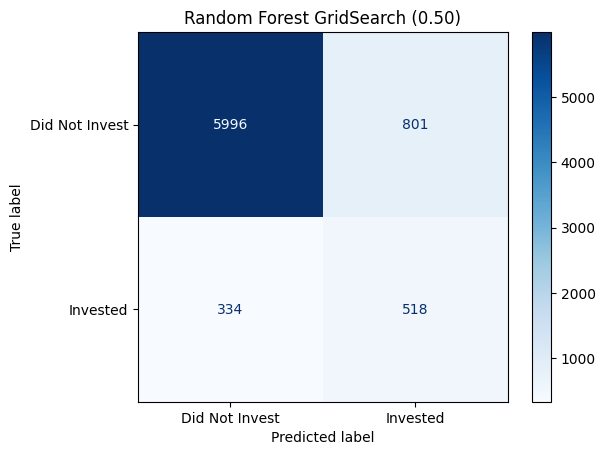

                precision    recall  f1-score   support

Did Not Invest      0.947     0.882     0.914      6797
      Invested      0.393     0.608     0.477       852

      accuracy                          0.852      7649
     macro avg      0.670     0.745     0.695      7649
  weighted avg      0.885     0.852     0.865      7649



In [23]:
# Setup GridSearchCV
rf_param_grid = {
    'n_estimators': [300, 500],
    'max_depth': [6, 8, 12, None],
    'min_samples_leaf': [2, 10, 15, 20]
}

# Train RF with GridSearchCV
rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42),
    rf_param_grid,
    cv=10,
    scoring='roc_auc', 
    n_jobs=-1,
    verbose=1
)
rf_grid.fit(X_train_rf, y_train)
best_pipeline_rf = rf_grid.best_estimator_

# Evaluate best RF model
print("Best Params:", rf_grid.best_params_)
print(f"Best CV Recall: {rf_grid.best_score_:.4f}")
evaluate(best_pipeline_rf, X_test_rf, y_test, "Random Forest GridSearch (0.50)")

### Random Forest GridSearch - Tuned (0.35) - Model 4

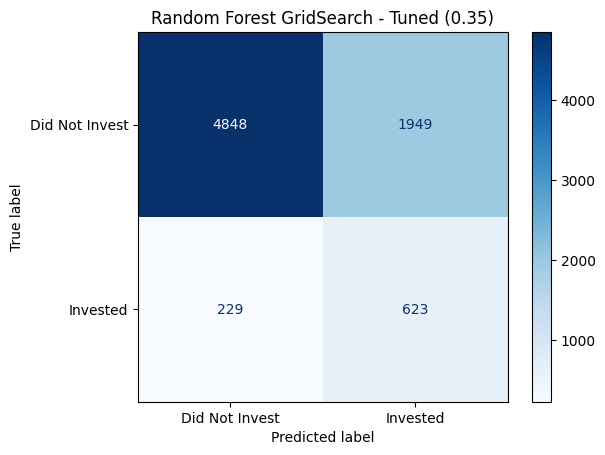

                precision    recall  f1-score   support

Did Not Invest       0.95      0.71      0.82      6797
      Invested       0.24      0.73      0.36       852

      accuracy                           0.72      7649
     macro avg       0.60      0.72      0.59      7649
  weighted avg       0.88      0.72      0.77      7649



In [24]:
evaluate_tune(0.35, y_prob, y_test, "Random Forest GridSearch - Tuned (0.35)")

## Final Random Forest Comparison

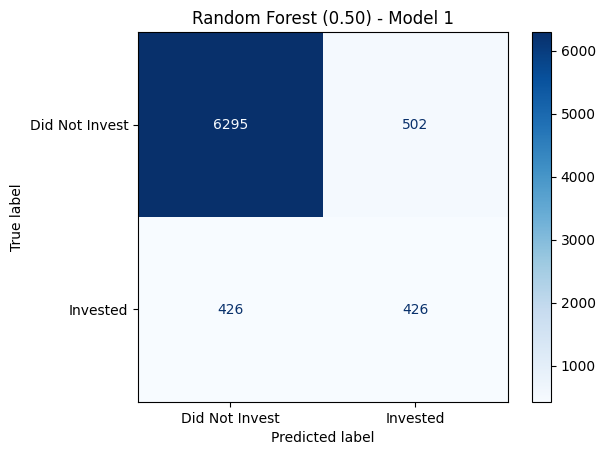

                precision    recall  f1-score   support

Did Not Invest      0.937     0.926     0.931      6797
      Invested      0.459     0.500     0.479       852

      accuracy                          0.879      7649
     macro avg      0.698     0.713     0.705      7649
  weighted avg      0.883     0.879     0.881      7649



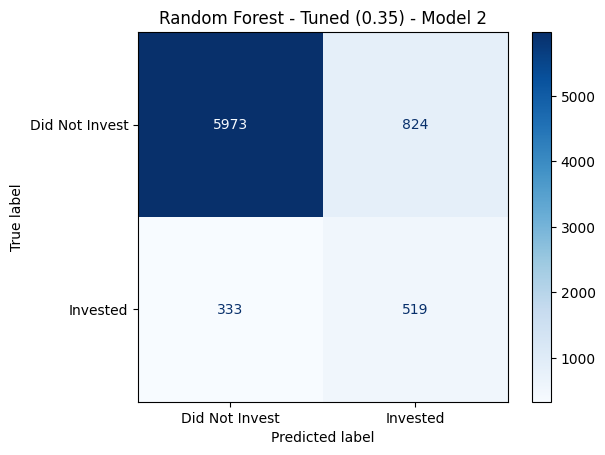

                precision    recall  f1-score   support

Did Not Invest       0.95      0.88      0.91      6797
      Invested       0.39      0.61      0.47       852

      accuracy                           0.85      7649
     macro avg       0.67      0.74      0.69      7649
  weighted avg       0.88      0.85      0.86      7649



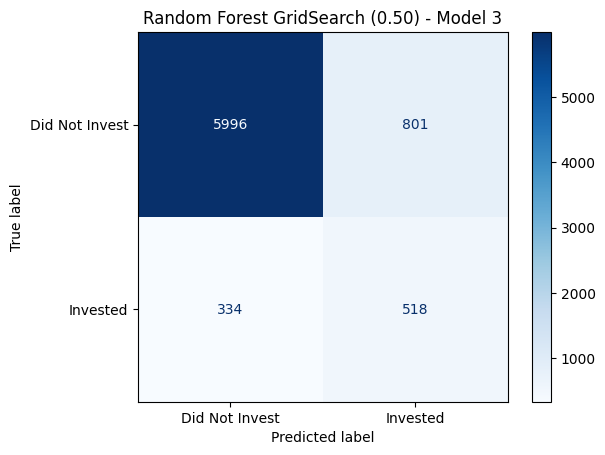

                precision    recall  f1-score   support

Did Not Invest      0.947     0.882     0.914      6797
      Invested      0.393     0.608     0.477       852

      accuracy                          0.852      7649
     macro avg      0.670     0.745     0.695      7649
  weighted avg      0.885     0.852     0.865      7649



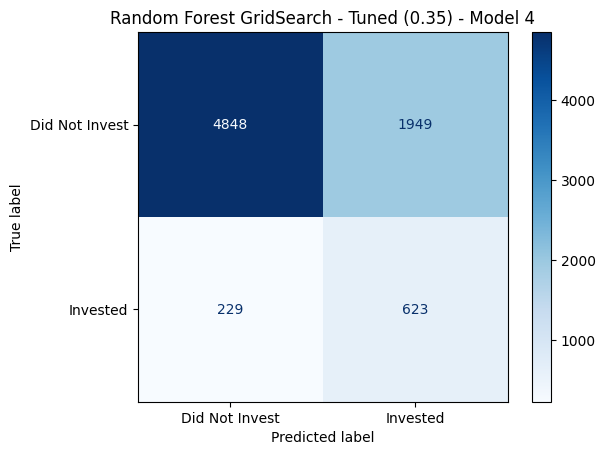

                precision    recall  f1-score   support

Did Not Invest       0.95      0.71      0.82      6797
      Invested       0.24      0.73      0.36       852

      accuracy                           0.72      7649
     macro avg       0.60      0.72      0.59      7649
  weighted avg       0.88      0.72      0.77      7649



In [25]:
evaluate(rf1, X_test_rf, y_test, "Random Forest (0.50) - Model 1")
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_test, y_pred_rf_tuned),
    display_labels=['Did Not Invest', 'Invested']
).plot(cmap='Blues')
plt.title('Random Forest - Tuned (0.35) - Model 2')
plt.show()
print(classification_report(y_test, y_pred_rf_tuned, target_names=['Did Not Invest', 'Invested']))
evaluate(best_pipeline_rf, X_test_rf, y_test, "Random Forest GridSearch (0.50) - Model 3")
evaluate_tune(0.35, y_prob, y_test, "Random Forest GridSearch - Tuned (0.35) - Model 4")

GridSearchCV showed that we already had strong hyperparameters in Model 2, with the search returning nearly identical results. The threshold tuning proved to be effective in increasing recall, which correctly identified 105 additional investors that the default threshold would have missed. When we later compare this to our logistic regression, we can compare the precision and recall tradeoff to evaluate which model will be more valuable in our business context.

# Conclusion

## Model Selection
To identify the best model from each approach, we want to use the GridSearch models with a tuned threshold of 0.35 from both methods. Though these models are not the best in terms of overall performance, they have a high recall rate for the positive class (those who actually invested). We are again prioritizing this because though we want the bank to have a higher efficiency, missing out on calls to people that would invest is a crucial mistake. Our best two options given this business context are visible in the screenshots below. 

![LogReg Final Model](../final_model_images/logreg4.png)

![RF Final Model](../final_model_images/rf4.png)

## Interpreting the results
Both logistic regression and random forest models address our central question of how to identify the customers most likely to subscribe to a term deposit so the bank can optimize the efficiency of their outreach campaign and reduce uncecessary calls. However, it was important for us to understand that this problem was inherently imbalanced. Only about 11% of the potential clients in this dataset actually subsribed to the deposit. This low prevalence means that a strategy of simply calling everyone wastes a lot of time, since it would yield a precision of only about 0.11. The imbalance also required us to adjust parts of our modeling process, such as the use of "class_weight='balanced'" and lowering the decision thresholds for both models to 0.35. This threshold adjustment was crucial to capturing more of the target class. Without this change, the models had a lower recall for the positive class by, in most cases, 0.1 or more. 

## Comparing the two best models
After GridSearchCV and threshold tuning, both models performed similarly. Logistic regression achieved slightly higher recall for the positive class (0.77 vs. 0.73) while random forest was marginally more precise (0.24 vs. 0.20). The random forest model also had an accuracy of 0.72, which was significantly higher than the logistic regression model coming in at an accuracy of 0.63. Considering this, the best model is likely the Random Forest model because of its slightly better tradeoff between recall and precision. Though the logistic regression model has a higher recall, it has a worse recall-precision tradeoff compared to the RF model.

The main limitation is that about 1 out of 4 customers that are flagged by our chosen model at best will actually subscribe to the term deposit. However, this tradeoff is acceptable tradeoff given that a wasted call costs much less than missing a call for someone that would have subscribed. The model should be treated as a prioritization.

# Team Contributions

**Nathan's contributions:**
* Worked with the team to choose and establish the data and perform EDA to decide which varibles to keep for our model. 
* Tested and interpreted the results of teammates' work on the baseline RF and LogReg models. 
* Completed the GridSearchCV sections for both Logistic Regression and Random Forest models.
* Collaborated with the team to decide which model to select and then wrote the conclusion section.
* Cleaned and edited the final notebook to ensure there were no errors and the logic/flow of the notebook made sense. 

**Erik's Contributions**
* Worked with the team to select the dataset, clean it, and perform EDA to select variables to use for the model
* Wrote the introduction section that explains why we decided to explore this dataset and lays out the process of what we are going to do for the process.
* Performed Logistic Regression on the data to see how well potential investors can be identified.
* Adjusted the threshold of the model to see if it could recognize future investors at a better rate.
* Plotted the curves for precision and recall to find a balance between the two.
* Collaborated with the team to see if there were any other improvements that can be made to the model and what model to select.


**Ethan's Contributions**
- Worked with team to decide on a dataset for the project, performing data prep and formatting of notebook
- Created Random Forest data prep & models 
- Organized our collective work into 1 singular notebook to create a story/narrative around the prediction question
- Created evaluation functions for reproducibility across the notebook
- Collaborated with team to choose certain data prep features as well as final model decisions and narrative decisions